<a href="https://colab.research.google.com/github/Abdi-dotcom/Construction--equipment-Tracking/blob/main/Deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive


In [2]:
drive.mount('/content/drive/')

Mounted at /content/drive/


In [3]:

file_path = '/content/drive/MyDrive/Colab Notebooks/used_cars.csv'
car = pd.read_csv(file_path)

In [4]:
car.head(5)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [5]:
car.shape

(4009, 12)

In [6]:
milage = car["milage"]
milage = milage.str.replace(",", "")
milage = milage.str.replace(" mi.", "")
milage = milage.astype(int)
print(milage)

0       51000
1       34742
2       22372
3       88900
4        9835
        ...  
4004      714
4005    10900
4006     2116
4007    33000
4008    43000
Name: milage, Length: 4009, dtype: int64


In [7]:
age = car["model_year"].max() - car["model_year"]
print(age)

0       11
1        3
2        2
3        9
4        3
        ..
4004     1
4005     2
4006     2
4007     4
4008     4
Name: model_year, Length: 4009, dtype: int64


In [8]:
price = car["price"]
price = price.str.replace("$", "")
price = price.str.replace(",", "")
price = price.astype(int)
print(price)

0        10300
1        38005
2        54598
3        15500
4        34999
         ...  
4004    349950
4005     53900
4006     90998
4007     62999
4008     40000
Name: price, Length: 4009, dtype: int64


In [9]:
X = torch.stack([torch.tensor(milage, dtype=torch.float32),
                 torch.tensor(age, dtype=torch.float32)], dim=1)
print(X)
print(X.shape)

tensor([[5.1000e+04, 1.1000e+01],
        [3.4742e+04, 3.0000e+00],
        [2.2372e+04, 2.0000e+00],
        ...,
        [2.1160e+03, 2.0000e+00],
        [3.3000e+04, 4.0000e+00],
        [4.3000e+04, 4.0000e+00]])
torch.Size([4009, 2])


In [10]:
Y= torch.tensor(price, dtype=torch.float32).reshape((-1,1))
print(Y)
print(Y.shape)

tensor([[10300.],
        [38005.],
        [54598.],
        ...,
        [90998.],
        [62999.],
        [40000.]])
torch.Size([4009, 1])


In [11]:
X_mean = X.mean(dim=0)
X_std = X.std(dim=0)
X = (X - X_mean) / X_std
print(X_mean)
print(X_std)
print(X)

tensor([6.4718e+04, 8.4844e+00])
tensor([5.2297e+04, 6.1048e+00])
tensor([[-0.2623,  0.4121],
        [-0.5732, -0.8984],
        [-0.8097, -1.0622],
        ...,
        [-1.1970, -1.0622],
        [-0.6065, -0.7346],
        [-0.4153, -0.7346]])


In [12]:
Y_mean = Y.mean(dim=0)
Y_std = Y.std()
Y = (Y - Y_mean) / Y_std
print(Y_mean)
print(Y_std)
print(Y)

tensor([44553.1875])
tensor(78710.6328)
tensor([[-0.4352],
        [-0.0832],
        [ 0.1276],
        ...,
        [ 0.5901],
        [ 0.2343],
        [-0.0578]])


In [13]:
# define model
model = nn.Linear(2, 1)

In [14]:
#define loss function
criteria = nn.MSELoss()

In [15]:
#define optimiser
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

Training a Neural Network

In [16]:
epochs = 1000 # number of times passes through the entire training set
losses = []
for i in range(0, epochs):
  optimizer.zero_grad()
  preds = model(X)
  loss = criteria(preds, Y)
  loss.backward()
  optimizer.step()

  if i% 100 == 0:
    print ("loss: ", loss)
  losses.append(loss.item())

loss:  tensor(1.3873, grad_fn=<MseLossBackward0>)
loss:  tensor(0.9194, grad_fn=<MseLossBackward0>)
loss:  tensor(0.9077, grad_fn=<MseLossBackward0>)
loss:  tensor(0.9065, grad_fn=<MseLossBackward0>)
loss:  tensor(0.9063, grad_fn=<MseLossBackward0>)
loss:  tensor(0.9063, grad_fn=<MseLossBackward0>)
loss:  tensor(0.9062, grad_fn=<MseLossBackward0>)
loss:  tensor(0.9062, grad_fn=<MseLossBackward0>)
loss:  tensor(0.9062, grad_fn=<MseLossBackward0>)
loss:  tensor(0.9062, grad_fn=<MseLossBackward0>)


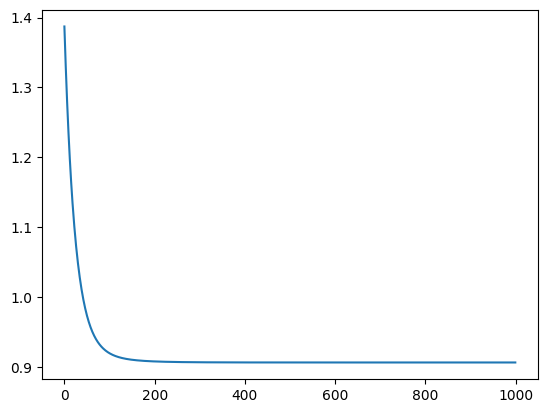

In [17]:
plt.plot(losses)
plt.show()

Making predications

In [18]:
from numpy import dtype
model.eval()
with torch.no_grad():
  X_new = torch.tensor([
      [10000, 2],
      [20000, 2]
      ],dtype = torch.float32)
  X_new = (X_new - X_mean) / X_std
  Prediction = model(X_new)
  Prediction = (Prediction * Y_std) + Y_mean
  print(Prediction)

tensor([[70284.4375],
        [65846.4609]])
